In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## Step 1: Load Data

The Wine dataset has 178 samples and 13 features — too many to plot directly.

In [2]:
wine = load_wine()
X = wine.data
print("Shape:", X.shape)

Shape: (178, 13)


## Step 2: Scale, then Apply PCA

We reduce the 13 features down to just 2 principal components, so we can visualize the data.

In [3]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"These 2 components explain {pca.explained_variance_ratio_.sum()*100:.1f}% of the variance")

These 2 components explain 55.4% of the variance


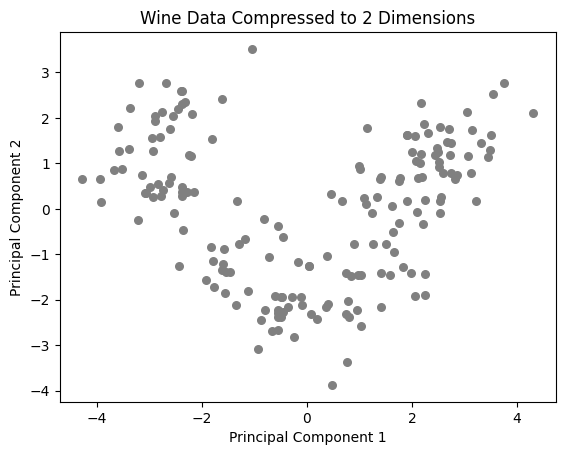

In [4]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=30, color='gray')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Wine Data Compressed to 2 Dimensions')
plt.show()

13 features are now just 2 — and you can already see natural groupings by eye, before running any clustering.

## Step 3: Cluster the PCA-Reduced Data with K-Means

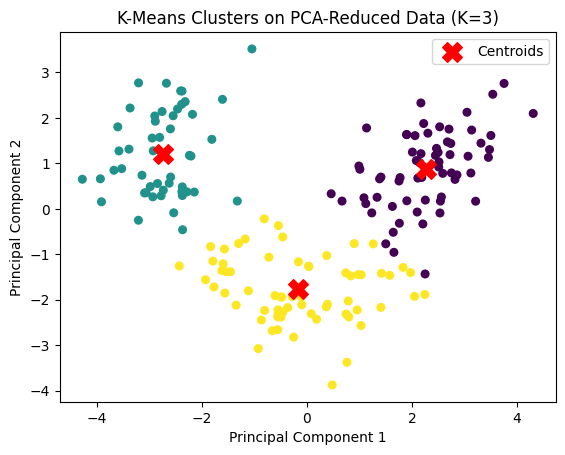

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters on PCA-Reduced Data (K=3)')
plt.legend()
plt.show()

## Summary

- PCA compressed 13 wine features down to 2 principal components, keeping most of the important information.
- K-Means was then able to cluster the simplified data into 3 groups and we could actually visualize the result.
- This PCA-then-cluster combo is a common way to handle and visualize data that has too many features to plot directly.

See `PCA_Clustering_Concepts.md` for the full explanation of the concepts used here.